In [180]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [181]:
import polyphase as phase
import numpy as np
import math as mt
import csv

In [182]:
def load_database(filename):
    with open(filename, mode='r', newline='') as file:
        reader = csv.DictReader(file)
        return {row['Solvent'].strip().lower(): row for row in reader}

In [183]:
A = load_database('Green_Solvent_PBTTT_PMMA_PS.csv')
A

{'1-butanol': OrderedDict([('.', '1'),
              ('Solvent', '1-Butanol'),
              ('T (MPa^0.5)', '23.2'),
              ('dD (MPa^0.5)', '16'),
              ('dP (MPa^0.5)', '5.7'),
              ('dH (MPa^0.5)', '15.8'),
              ('Vm (cm3/mol)', '91.5'),
              ('Sol.', '1'),
              ('RE', '2')]),
 'dioxane': OrderedDict([('.', '2'),
              ('Solvent', 'Dioxane'),
              ('T (MPa^0.5)', '20.47'),
              ('dD (MPa^0.5)', '19'),
              ('dP (MPa^0.5)', '1.8'),
              ('dH (MPa^0.5)', '7.4'),
              ('Vm (cm3/mol)', '85.7'),
              ('Sol.', '1'),
              ('RE', '0')]),
 '2-methoxyethanol': OrderedDict([('.', '3'),
              ('Solvent', '2-Methoxyethanol'),
              ('T (MPa^0.5)', '24.82'),
              ('dD (MPa^0.5)', '16.2'),
              ('dP (MPa^0.5)', '9.2'),
              ('dH (MPa^0.5)', '16.4'),
              ('Vm (cm3/mol)', '79'),
              ('Sol.', '0'),
              ('RE'

In [184]:
solvents = list(A.keys())
#solvents = np.delete(solvents, [9, 10, 11])  # remove useless rows


hansen_s = np.array([
    [float(A[s]['Vm (cm3/mol)']),float(A[s]['dD (MPa^0.5)']), float(A[s]['dP (MPa^0.5)']), float(A[s]['dH (MPa^0.5)'])]
    for s in solvents])

In [185]:
T = 298.15 # K
R = 8.314 # J/(mol*K)

In [186]:
Dopant = 'ps'
Polymer = 'pbttt'

V_d = float(A[Dopant]['Vm (cm3/mol)']) # cm^3/mol
V_p = float(A[Polymer]['Vm (cm3/mol)']) # cm^3/mol

dD_d = float(A[Dopant]['dD (MPa^0.5)']) # MPa^1/2
dP_d = float(A[Dopant]['dP (MPa^0.5)']) # MPa^1/2
dH_d = float(A[Dopant]['dH (MPa^0.5)']) # MPa^1/2

dD_p = float(A[Polymer]['dD (MPa^0.5)']) # MPa^1/2
dP_p = float(A[Polymer]['dP (MPa^0.5)']) # MPa^1/2
dH_p = float(A[Polymer]['dH (MPa^0.5)']) # MPa^1/2

In [187]:
n = len(hansen_s) - 4

Radius = np.zeros((n, 3))
N = np.zeros((n, 3))
X = np.zeros((n, 3))
X_cr = np.zeros((n, 3))

for i in range(n):
    Radius[i, 0] = mt.sqrt(4*(dD_p - hansen_s[i,1])**2 + (dP_p - hansen_s[i,2])**2 + (dH_p - hansen_s[i,3])**2)  # polymer1 vs solvent3 
    Radius[i, 1] = mt.sqrt(4*(dD_d - hansen_s[i,1])**2 + (dP_d - hansen_s[i,2])**2 + (dH_d - hansen_s[i,3])**2)  # dopant2 vs solvent3 
    Radius[i, 2] = mt.sqrt(4*(dD_p - dD_d)**2 + (dP_p - dP_d)**2 + (dH_p - dH_d)**2) # polymer1 vs dopant2

    N[i, 0] = V_p / hansen_s[i, 0] # polymer vs solvent
    N[i, 1] = V_d / hansen_s[i, 0] # dopant vs solvent
    N[i, 2] = 1 # solvent vs solvent

    X[i, 0] = (hansen_s[i,0] * Radius[i,0]**2 / (4*R*T)) + 0.34 # polymer vs solvent
    X[i, 1] = (hansen_s[i,0] * Radius[i,1]**2 / (4*R*T)) + 0.2 # dopant vs solvent
    X[i, 2] = (hansen_s[i,0] * Radius[i,2]**2 / (4*R*T)) # polymer vs dopant

    X12_cr[i, 0] = 1/2 * (1/mt.sqrt(N[i,0]) + 1/mt.sqrt(N[i,1]))**2 # polymer vs dopant
    X13_cr[i, 1] = 1/2 * (1/mt.sqrt(N[i,0]) + 1/mt.sqrt(N[i,2]))**2 # polymer vs solvent
    X23_cr[i, 2] = 1/2 * (1/mt.sqrt(N[i,2]) + 1/mt.sqrt(N[i,1]))**2 # dopant vs solvent

In [188]:
Crit = np.zeros((n, 3))  

for i in range(n):
    for j in range(3):
        if X[i, j] >= X_cr[i, j]:
            Crit[i, j] = 1
        else:
            Crit[i, j] = 0

Crit

array([[1., 1., 0.],
       [0., 0., 0.],
       [1., 1., 0.],
       [1., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [1., 1., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [1., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [1., 1., 0.],
       [1., 1., 0.],
       [1., 1., 0.],
       [1., 1., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [1., 1., 0.],
       [1., 1., 0.],
       [1., 1., 0.],
       [1., 0., 0.],
       [0., 0., 0.],
       [1., 1., 0.],
       [0., 0., 0.],
       [1., 1., 0.],
       [1., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

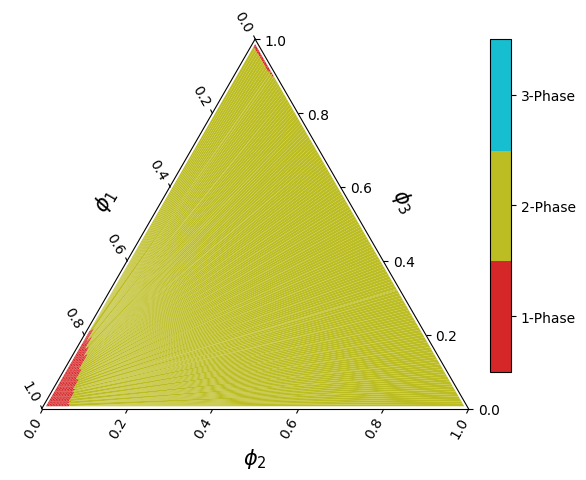

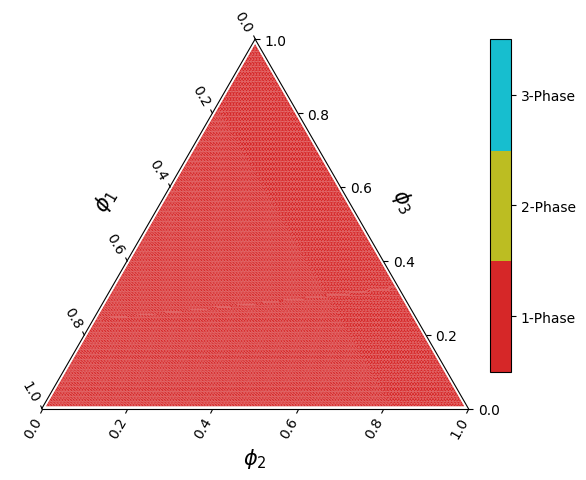

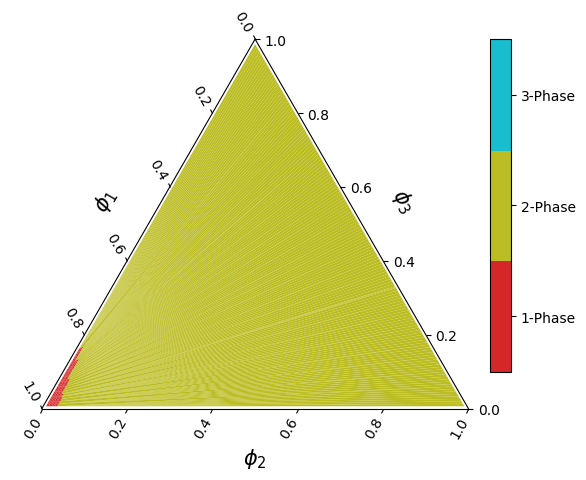

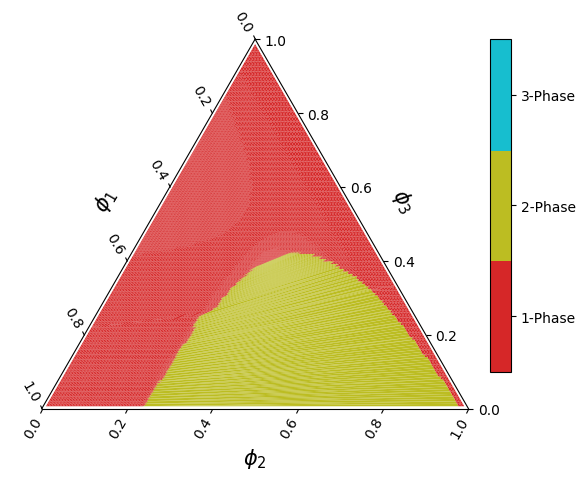

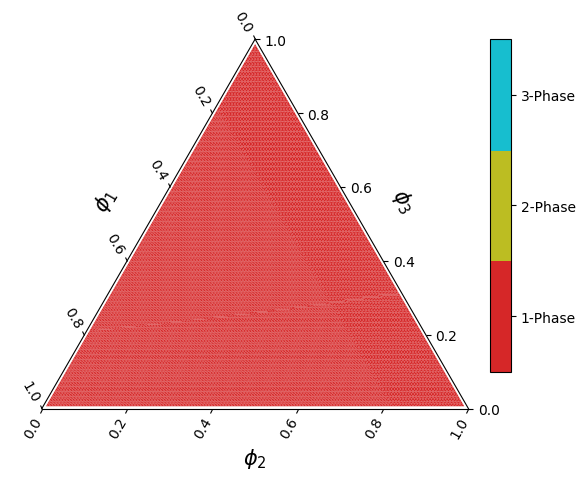

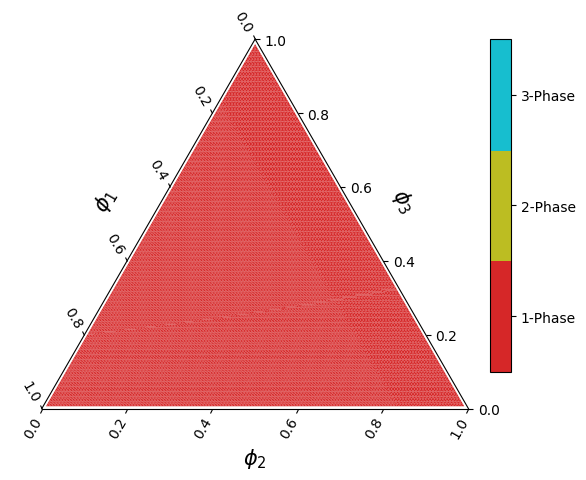

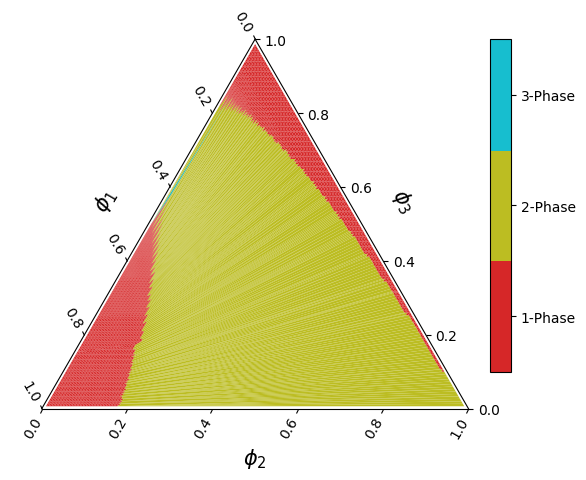

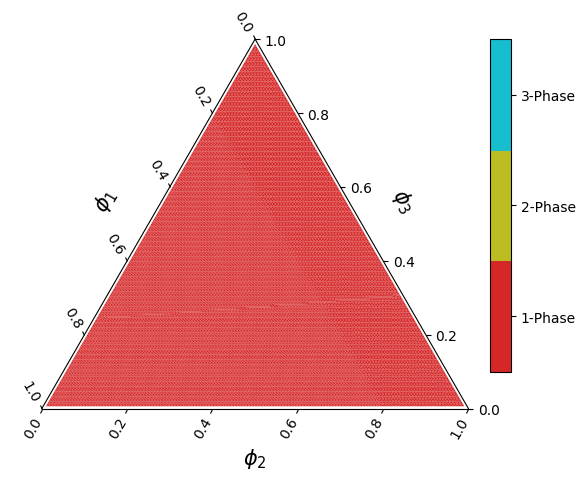

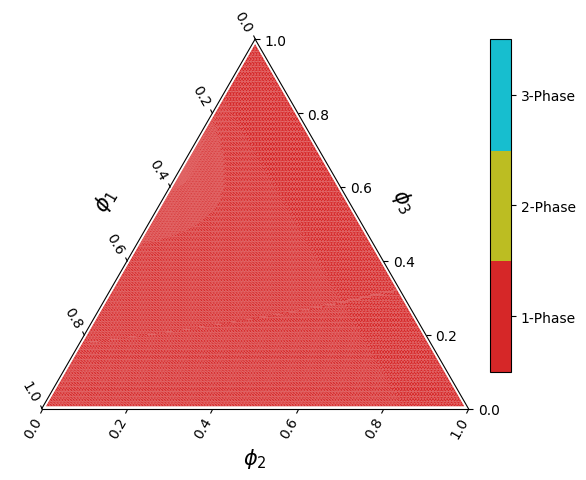

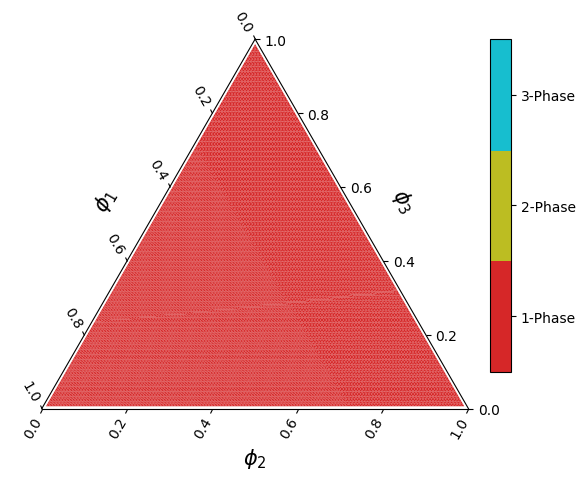

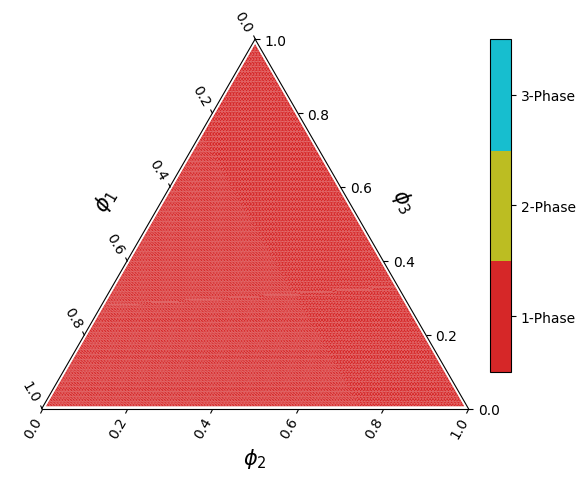

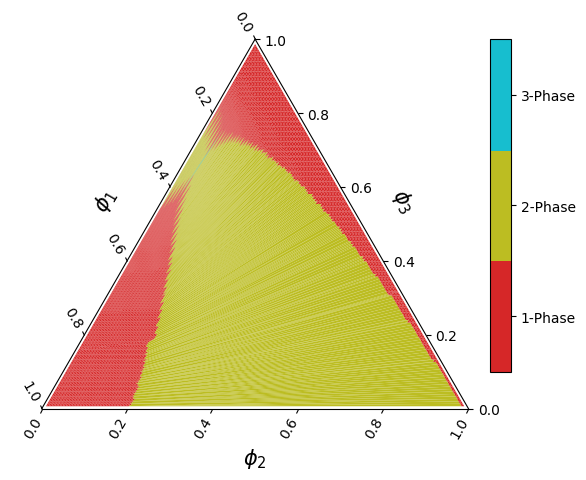

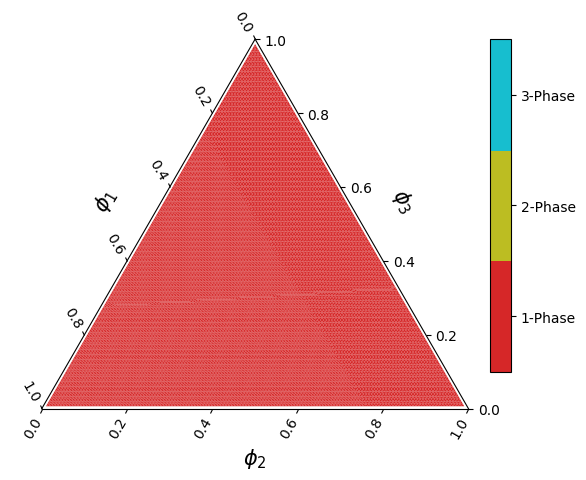

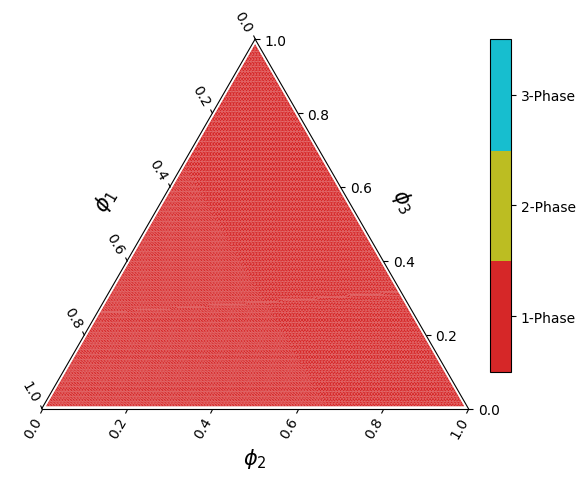

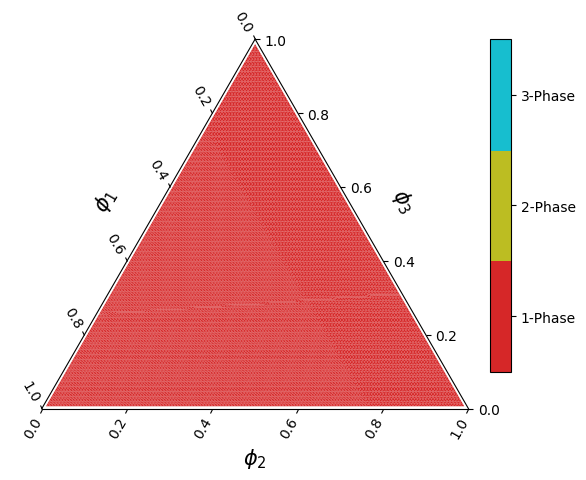

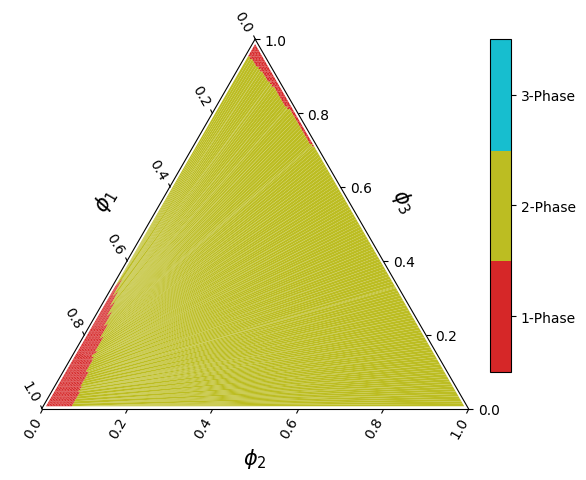

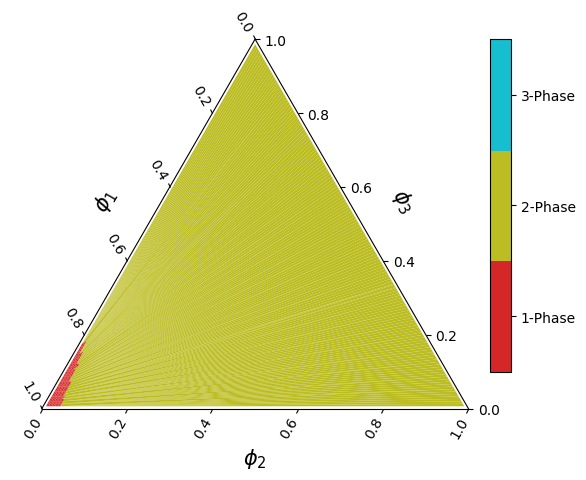

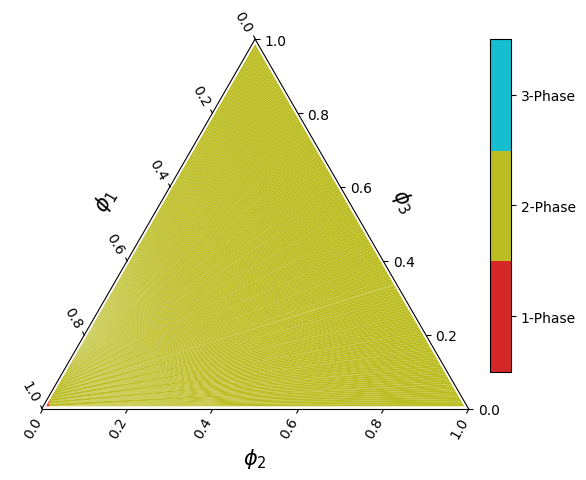

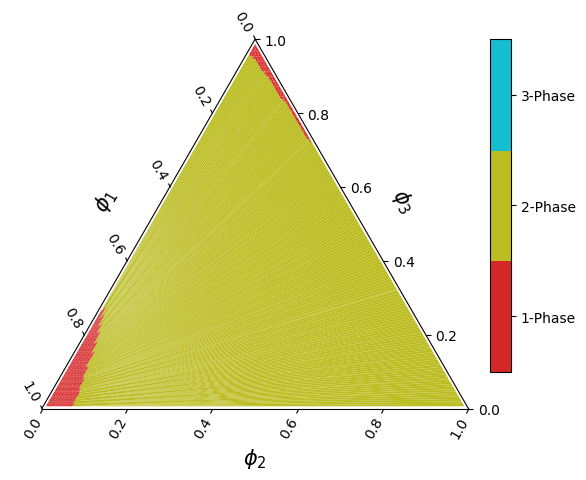

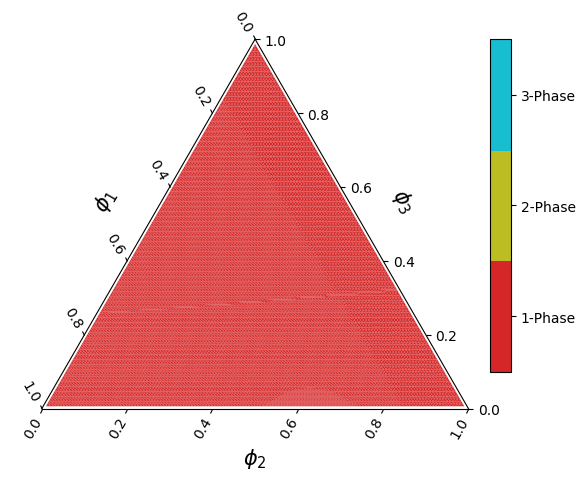

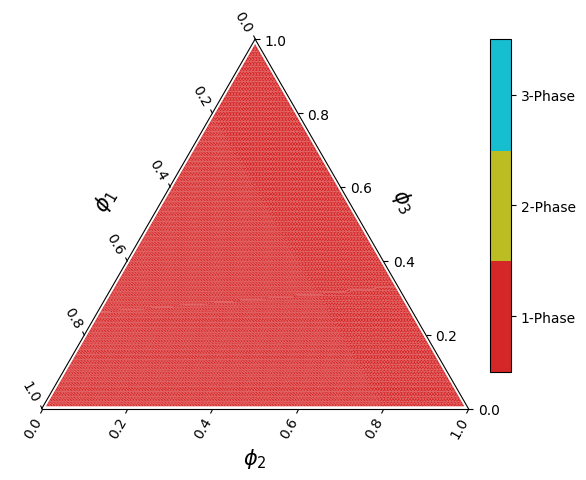

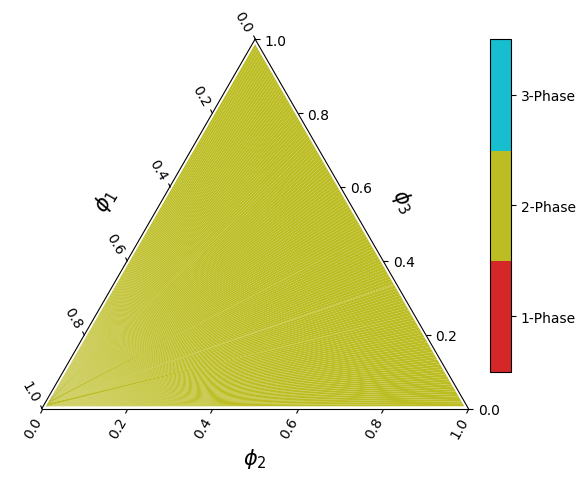

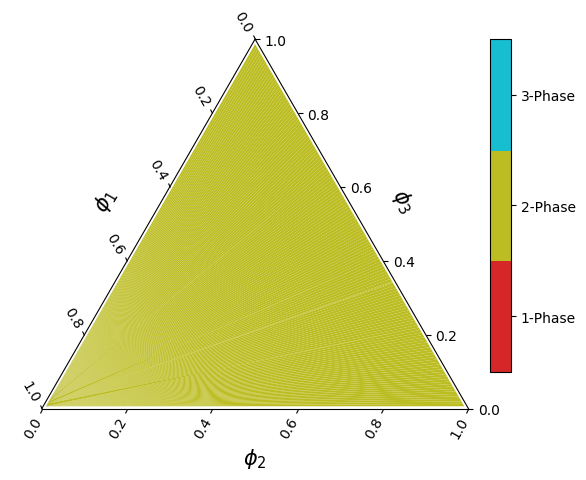

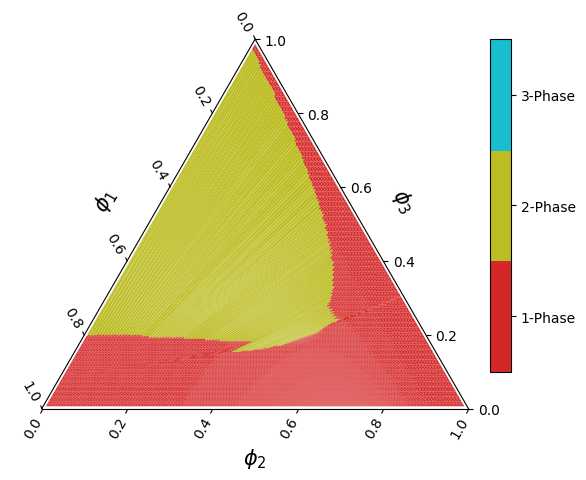

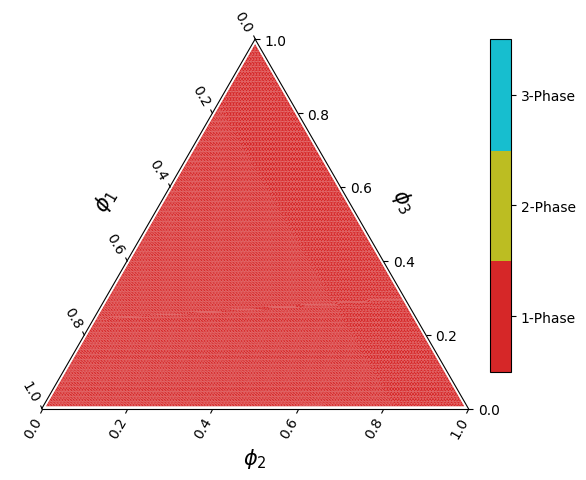

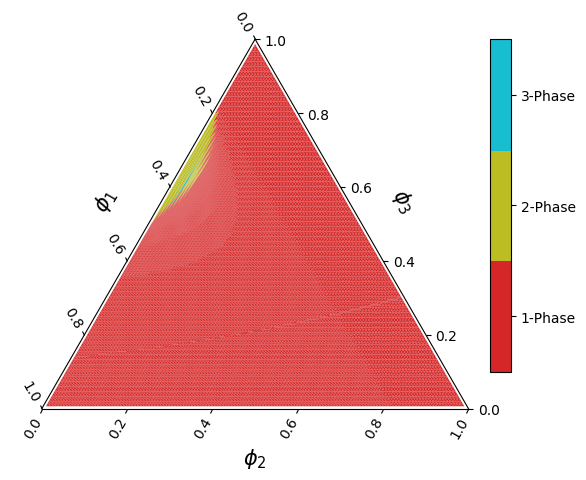

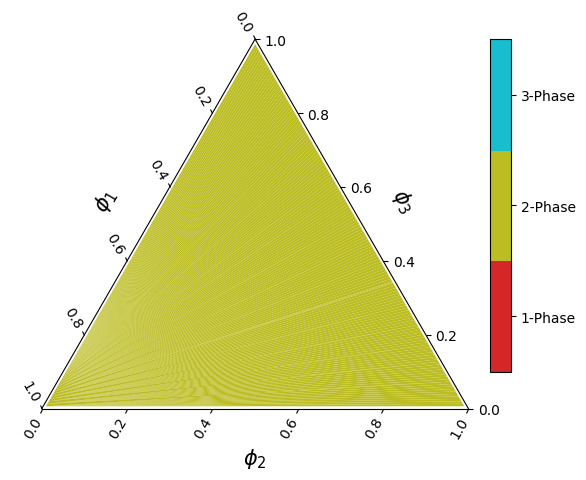

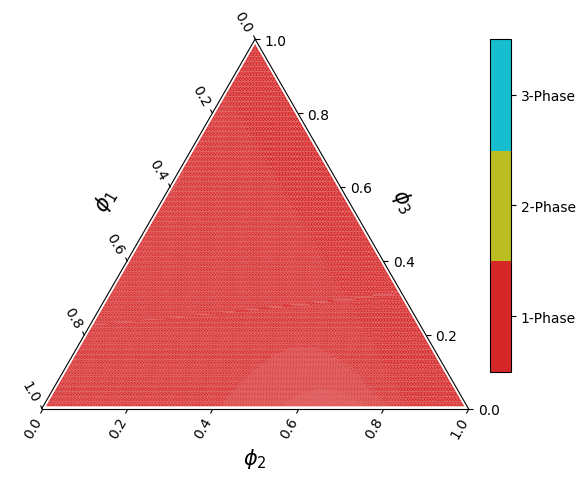

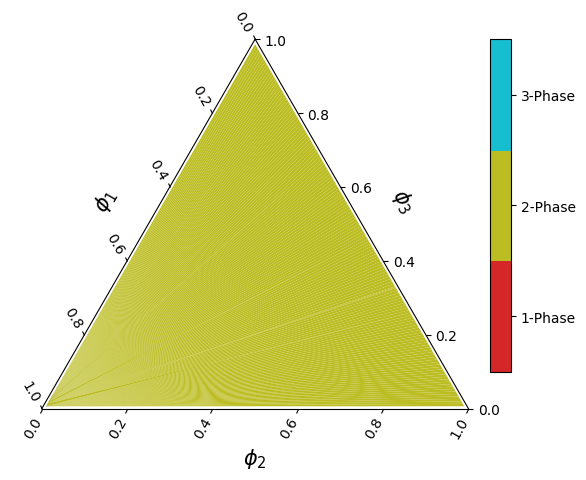

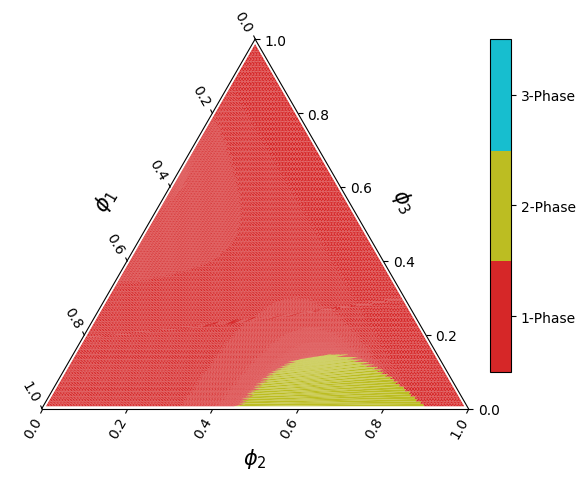

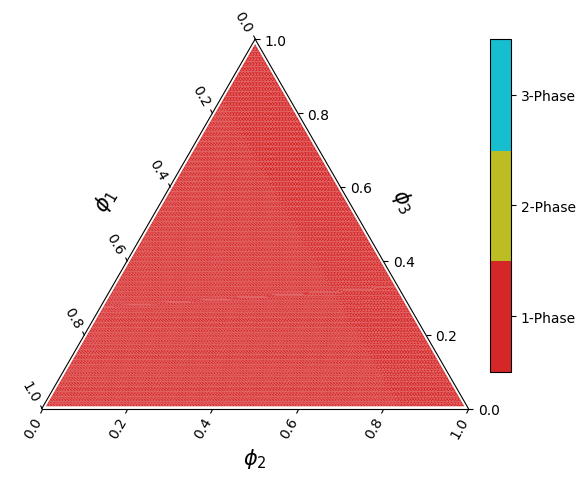

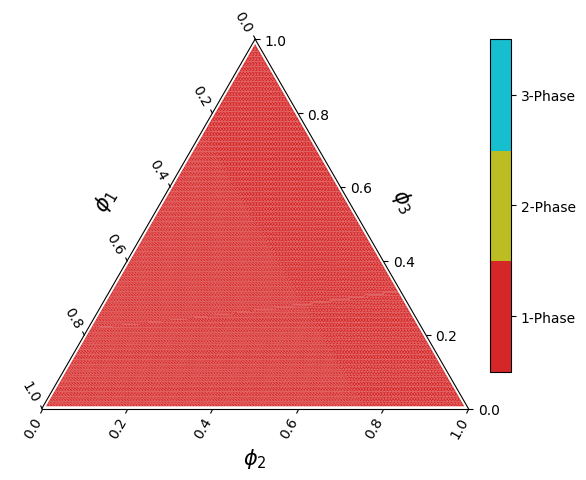

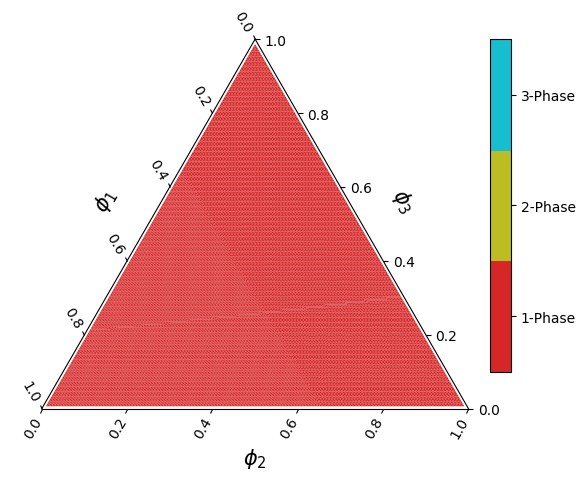

In [189]:
import matplotlib.pyplot as plt

B = list(A.keys())
np.delete(B, [len(B)-2,len(B)-1])

engines = []
id = 0;
for i in range(n):
    M = N[i, :]
    chi = X[i, :]
    f = lambda x, M=M, chi=chi: phase.flory_huggins(x, M, chi) 
    engine = phase.PHASE(f, 150, 3)
    engine.compute(use_parallel=False, verbose=False, lift_label=True) 
    engine.plot(filename=f"{B[id]}.png")
    id = id + 1

In [190]:
N

array([[ 6.64043716,  1.08415301,  1.        ],
       [ 7.08984831,  1.15752625,  1.        ],
       [ 7.69113924,  1.2556962 ,  1.        ],
       [ 8.21081081,  1.34054054,  1.        ],
       [ 5.17546848,  0.84497445,  1.        ],
       [ 6.79642058,  1.10961969,  1.        ],
       [ 5.86486486,  0.95752896,  1.        ],
       [ 4.58566038,  0.74867925,  1.        ],
       [ 6.25746653,  1.02162719,  1.        ],
       [ 5.94520548,  0.97064579,  1.        ],
       [ 7.5291202 ,  1.22924411,  1.        ],
       [ 5.73207547,  0.93584906,  1.        ],
       [ 6.78882682,  1.10837989,  1.        ],
       [ 5.37699115,  0.87787611,  1.        ],
       [ 5.0214876 ,  0.81983471,  1.        ],
       [ 7.89090909,  1.28831169,  1.        ],
       [ 8.52173913,  1.39130435,  1.        ],
       [10.38632479,  1.6957265 ,  1.        ],
       [ 6.21267894,  1.01431493,  1.        ],
       [ 6.16852792,  1.0071066 ,  1.        ],
       [ 7.65239295,  1.24937028,  1.   

In [192]:
hansen_s

array([[9.1500e+01, 1.6000e+01, 5.7000e+00, 1.5800e+01],
       [8.5700e+01, 1.9000e+01, 1.8000e+00, 7.4000e+00],
       [7.9000e+01, 1.6200e+01, 9.2000e+00, 1.6400e+01],
       [7.4000e+01, 1.5500e+01, 1.0400e+01, 7.0000e+00],
       [1.1740e+02, 1.9600e+01, 8.6000e+00, 3.7000e+00],
       [8.9400e+01, 1.8400e+01, 0.0000e+00, 2.0000e+00],
       [1.0360e+02, 1.8400e+01, 6.3000e+00, 1.3700e+01],
       [1.3250e+02, 1.5800e+01, 3.7000e+00, 6.3000e+00],
       [9.7100e+01, 1.7800e+01, 0.0000e+00, 6.0000e-01],
       [1.0220e+02, 1.9000e+01, 4.3000e+00, 2.0000e+00],
       [8.0700e+01, 1.7800e+01, 3.1000e+00, 5.7000e+00],
       [1.0600e+02, 1.7400e+01, 4.1000e+00, 1.3500e+01],
       [8.9500e+01, 1.6700e+01, 3.8000e+00, 5.2000e+00],
       [1.1300e+02, 1.8600e+01, 6.2000e+00, 3.2000e+00],
       [1.2100e+02, 1.6300e+01, 3.0000e+00, 6.0000e+00],
       [7.7000e+01, 1.7400e+01, 1.3700e+01, 1.1300e+01],
       [7.1300e+01, 1.8400e+01, 1.6400e+01, 1.0200e+01],
       [5.8500e+01, 1.5800e+01,

In [193]:
n

33